# van der Waals equation of state -- Chapter 7

## Goal of this notebook

The goal of this notebook is to reproduce the following figures in chapter 7 of Stanley I. Sandler, *Chemical, Biochemcial and Engineering Thermodynamics*, 5th ed. These illustrations are based on the van der Waals equation of state.

- Fig 7.3-1 -- five isotherms labeled with local maxima and minima
- Fig 7.3-2 -- a diagram showing the isotherm construction for a sub-critical temperature
- Fig 7.3-3 -- the resulting isotherm for a sub-critical temperature
- Fig 7.3-4 -- the van der Waals EOS PV diagram with multiple isotherms and two phase region

<small>
Copyright (c) 2025 Eric M. Furst


## van der Waals equation of state

Below are routines to calculate the van der Waals equation of state.

The van der Waals equation of state (vdW EOS) is

$$ P = \frac{RT}{\underline{V}-b} - \frac{a}{\underline{V}^2} \tag{Eq. 6.2-38b}$$

Like other cubic equations of state, calculating the pressure $P$ given $\underline{V}$ and $T$ is straightforward, but to calculate the molar volume given $P$ and $T$, we need to solve a cubic equation of the form

$$ Z^3 + \alpha Z^2 + \beta Z + \gamma = 0 \tag{Eq. 6.4-4}$$

where $Z$ is the compressibility factor

$$ Z = \frac{P \underline{V{}}}{RT} $$

For the van der Waals EOS (see SIS **Table 6.4-3**),

$$ \alpha = -1 - B $$
$$ \beta = A $$
$$ \gamma = -AB $$

and 

$$ A = \frac{aP}{(RT)^2} $$
$$ B = \frac{bP}{RT} $$

Here, we will use the reduced van der Waals equation of state

$$ \left ( P_r + \frac{3}{\underline{V}_r} \right )(3\underline{V}_r - 1) = 8T_r \tag{Eq. 6.6-6}$$

This can be written in the form 

$$ \underline{V}_r^3 + \alpha \underline{V}_r^2 + \beta \underline{V}_r + \gamma = 0 $$

with

$$\alpha = -\frac{P_r+8T_r}{3P_r}$$
$$\beta = \frac{3}{P_r}$$
$$\gamma = -\frac{1}{P_r}$$

which is left as an exercise for the reader.

In [1]:
"""
Reduced van der Waals equation of state 
rvdw_P returns the pressure given Vr, Tr
rvdw_V returns all reduced molar volumes (real roots of EOS) given Pr and Tr
"""
import numpy as np
from numpy.polynomial import Polynomial


# Calculate the reduced presure given Vr, Tr for reduced vdw EOS
def rvdw_P(Vr,Tr):

    return 8*Tr/(3*Vr-1) - 3/Vr**2

# Calculate the reduced molar volume given Pr, Tr
# Note that we can return multiple real roots (up to three)
# The largest and smallest will be the vapor and liquid, respectively
def rvdw_V(Pr, Tr):

    # Definitions of alpha, beta, gamma in SIS Table 6.4-3 for PR EOS
    alpha = -(Pr+8*Tr)/3/Pr
    beta = 3/Pr
    gamma = -1/Pr

    # polynomial with coefficients in increasing order: c0 + c1 x + c2 x**2 + ...
    p = Polynomial([ gamma, beta, alpha, 1 ])  

    roots = p.roots()        # returns all (possibly complex) roots of Z
    real_roots = roots.real[abs(roots.imag) < 1e-12]  # filter real ones

    return real_roots



# Figure 7.3-1 Isotherms of the van der Waals equation in the pressure-volume plane

This figure is similar to figure 6.6-1, but it labels the curves differently.

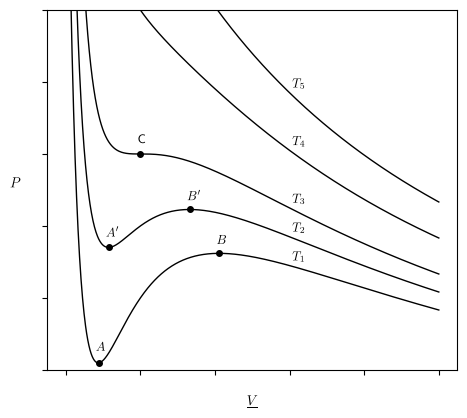

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.transforms import offset_copy

# Use a real LaTeX installation when there is one, so the figure is set in Computer
# Modern like the book, and fall back to matplotlib's own mathtext otherwise, which
# lets this notebook run in Colab too (Colab has no TeX). Verified: mathtext renders
# \underline correctly in the CM fontset.
from shutil import which
mpl.rcParams["text.usetex"] = which("latex") is not None
if not mpl.rcParams["text.usetex"]:
    # No LaTeX (Colab): keep a serif face and Computer Modern math so the
    # fallback still resembles the book. Deliberately NOT set when usetex is
    # on — there it changes the font LaTeX picks for non-math text and would
    # alter the printed art.
    mpl.rcParams.update({"font.family": "serif", "mathtext.fontset": "cm"})

# Good PDF defaults
mpl.rcParams.update({
    "pdf.fonttype": 42,   # keep text as text in PDF
    "ps.fonttype": 42,
})

# Function to make plot labels
def label_curve(ax, x, y, text, *, dx=2, dy=3, ha="left", va="bottom", fontsize=9, bbox=False):
    # Place a text label in data coordinates with a point offset.
    transform = offset_copy(ax.transData, fig=ax.figure, x=dx, y=dy, units="points")

    bbox_kw = None
    if bbox:
        bbox_kw = dict(facecolor="white", edgecolor="none", boxstyle="round,pad=0.2")

    ax.text(float(x), float(y), text, ha=ha, va=va, fontsize=fontsize, transform=transform,
        bbox=bbox_kw)

# Function to label local minimum and maximum for isotherms below Tc
def label_loop_extrema(ax, Vr, P, *, label_min="A", label_max="B",
                       dy_min=-8, dy_max=6, marker=True):
    # numerical derivative
    dP = np.gradient(P, Vr)
    s = np.sign(dP)

    # sign flips
    imax = np.where((s[:-1] > 0) & (s[1:] < 0))[0] + 1   # + to - : local max
    imin = np.where((s[:-1] < 0) & (s[1:] > 0))[0] + 1   # - to + : local min

    if len(imax) == 0 or len(imin) == 0:
        return None  # no loop/extrema found (near/above critical)

    iB = imax[0]   # local maximum
    iA = imin[0]   # local minimum

    if marker:
        ax.plot(Vr[iA], P[iA], "o", ms=4, color="black")
        ax.plot(Vr[iB], P[iB], "o", ms=4, color="black")

    label_curve(ax, Vr[iA], float(P[iA]), label_min, dx=-2, dy=dy_min, 
                ha="left", va="top", bbox=False)
    label_curve(ax, Vr[iB], float(P[iB]), label_max, dx =-2, dy=dy_max, 
                ha="left", va="bottom", bbox=False)

    return (Vr[iA], P[iA], Vr[iB], P[iB])

# Make the plot
fig, ax = plt.subplots(figsize=(5.0, 4.5))  # choose size you like

# Range of reduced molar volumes
Vr_max = 3
Vr_min = 0.5
Vr = np.linspace(Vr_min,Vr_max,1000)

"""
Plot five isotherms
"""
label_horiz_Vr = 2

# These are the labels for the sub-critical isotherm minima and maxima
extrema_labels = {
    0.9:  (r"$A$",  r"$B$"),
    0.95: (r"$A'$", r"$B'$"),
}

for k, Tr in enumerate([0.9, 0.95, 1.0, 1.1, 1.2], start=1):
    P = rvdw_P(Vr, Tr)
    ax.plot(Vr, P, '-', color="black", linewidth=1)

    # label the isotherm itself
    i = np.argmin(np.abs(Vr - label_horiz_Vr))
    label_curve(ax, Vr[i], float(P[i]), rf"$T_{k}$", dy=2)

    # label loop extrema for the subcritical ones
    labels = extrema_labels.get(Tr)
    if labels is not None:
        label_loop_extrema(
            ax, Vr, P,
            label_min=labels[0],
            label_max=labels[1],
            dy_min=15,
            dy_max=5
        )

# Mark and label the critical point
plt.plot(1, 1, "o", ms=4, color="black")
label_curve(ax, 1.0, float(np.asarray(rvdw_P(1.0, 1.0)).squeeze()), 
            "C", dx = -2, dy=6, bbox=True)

# Plot scaling and axes labels
plt.ylim([0.4,1.4])
plt.xlabel(r"$\underline{V}$", labelpad=15)
plt.ylabel(r'$P$', rotation=0, labelpad=20)

fig.tight_layout()

# Hide the tick labels
ax.tick_params(
    labelbottom=False,
    labelleft=False
)

# ---- SAVE HIGH-QUALITY PDF ----
import os
os.makedirs("pdf", exist_ok=True)   # Colab starts with no pdf/ directory
fig.savefig("pdf/Fig_7.3-1.pdf", bbox_inches="tight", pad_inches=0.02)

plt.show()

# Fugacity calculation for VLE

Next, we will build the vapor-liquid equilibrium line using a fugacity calculation. This will give us the vapor and liquid molar volumes at the vapor pressure. We use this to draw tie lines through the vapor-liquid equlibrium.

## Fugacity calculation for the van der Waals equation of state

The fugacity of the van der Waals equation of state is

$$ \ln \frac{f}{P} = (Z-1) -\ln (Z-B) - \frac{A}{Z} $$

First we define a function that evaluates the equation. Then we define a function to calculate the residual of the vapor and liquid fugacities.

In [3]:
"""Fugacity coefficient of the van der Waals EOS
Returns the natural log of the fugacity coefficient
"""
import numpy as np

def fugacity_vdw(Z,A,B):
    return (Z-1) - np.log(Z-B)-A/Z

### Residual calculation

The following function calculates the residual between the liquid and vapor fugacities from the EOS. We will use this and Newton's method to solve

$$ \ln \frac{f^V}{P} - \ln \frac{f^L}{P}  = 0$$

After defining the function, we test it with a calculation.

Newton's method will fail if the the reduced pressure guess is too far off. In this case, the pressure will be outside of the van der Waals loops of the isotherm. We can see this using the calculation above and noting the local maximum and minimum (reduced) pressures from the isotherms we plotted earlier.


In [4]:
# Function that returns the residual of the fugacity calculation
def residual_lnphi(Pr):
    """
    Returns ln(phi_L) - ln(phi_V) at given the reduced pressure Pr.
    At P_r^sat, this should be zero.
    As written, requires globals Tr
    """
    
    A = 27*Pr/64/Tr**2
    B = Pr/8/Tr

    # All compressibility roots
    V_real = rvdw_V(Pr,Tr)
    Z_real = V_real*Pr/Tr*3/8

    ZL = np.min(Z_real)  # liquid root (smallest Z)
    ZV = np.max(Z_real)  # vapor root (largest Z)

    ln_f_L = fugacity_vdw(ZL, A, B)  # ln(phi_L)
    ln_f_V = fugacity_vdw(ZV, A, B)  # ln(phi_V)

    return ln_f_L - ln_f_V

## Create a dataframe of the resulting VLE

With a method for calculating the vapor-liquid equilibrium line using fugacity, we construct a dataframe of the values. The dataframe will be a table that gives the equilibrium temperature, pressure, and molar volumes of the liquid and vapor in reduced values. We also include the vapor and liquid compressibility factors.

We use a large number of points to get close to the critical point. Each guess of the vapor pressure for a higher isotherm is the previous vapor pressure. 

In [5]:
import pandas as pd
from scipy.optimize import newton

# Temperature, pressure, and volume are in reduced units

# Example temperature grid
# Many points are used to keep the solver working near the c.p.
T_min = 0.62
T_max = 0.999
n_T   = 10000

T_list = np.linspace(T_min, T_max, n_T)

rows = []
P_guess = 0.2  # A good guess for Tr close to 0.7

for Tr in T_list:
    Psat = newton(residual_lnphi, P_guess)

    V_roots = np.array(rvdw_V(Psat, Tr), dtype=complex)
    V_real = V_roots[np.isreal(V_roots)].real
    V_real = V_real[np.isfinite(V_real)]

    if V_real.size == 0:
        rows.append({"T": Tr, "P": Psat, "vL": np.nan, "vV": np.nan})
        continue

    vL = V_real.min()
    vV = V_real.max()

    zL = vL*Psat/Tr*3/8
    zV = vV*Psat/Tr*3/8

    rows.append({"T": Tr, "P": Psat, "vL": vL, "vV": vV, "zL": zL, "zV": zV})
    P_guess = Psat

df_eq = pd.DataFrame(rows)
df_eq

,T,P,vL,vV,zL,zV
0,0.620000,0.104701,0.438683,14.146629,0.027781,0.895866
1,0.620038,0.104737,0.438695,14.142255,0.027789,0.895842
2,0.620076,0.104773,0.438707,14.137883,0.027798,0.895818
3,0.620114,0.104809,0.438719,14.133512,0.027806,0.895794
4,0.620152,0.104845,0.438731,14.129143,0.027815,0.895770
...,...,...,...,...,...,...
9995,0.998848,0.995400,0.936057,1.072259,0.349809,0.400709
9996,0.998886,0.995551,0.937057,1.070984,0.350223,0.400278
9997,0.998924,0.995702,0.938076,1.069691,0.350644,0.399840
9998,0.998962,0.995854,0.939116,1.068376,0.351073,0.399394


# Figure 7.3-2 A low-temperature isotherm of the van der Waals equation

Here we reconstruct Figure 7.3-2, which shows an isotherm below $T_c$.

This is a busy plot. We have to identify and label points on the curve. Several helper functions are defined in order to create the labels.

In [6]:
""" 
These are helper functions for generating plot 7.3-2

find_loop_extrema -- finds the local min and max of the isotherm
draw_loop_extrema -- labels the local min and max
root_between_extrema_bisect -- finds the unstable solution molar volume
label_bottom_axis -- routine for adding bottom axis labels
label_left_axis -- routine for adding left axis labels
"""


# --- Find the local maximum and minimum along a van der Waals loop
def find_loop_extrema(Vr, P):
    """
    Find local minimum (A) and local maximum (B) on a vdW loop.

    Returns a dict with:
      - iA, VA, PA : index/coords of local minimum
      - iB, VB, PB : index/coords of local maximum
    or None if no extrema are found.
    """
    Vr = np.asarray(Vr)
    P  = np.asarray(P)

    dP = np.gradient(P, Vr)
    s  = np.sign(dP)

    imax = np.where((s[:-1] > 0) & (s[1:] < 0))[0] + 1  # + -> - : max
    imin = np.where((s[:-1] < 0) & (s[1:] > 0))[0] + 1  # - -> + : min

    if len(imax) == 0 or len(imin) == 0:
        return None

    iB = int(imax[0])
    iA = int(imin[0])

    return {
        "iA": iA, "VA": float(Vr[iA]), "PA": float(P[iA]),
        "iB": iB, "VB": float(Vr[iB]), "PB": float(P[iB]),
    }

# --- Given a minimum or maximum, label the point on the curve
def draw_loop_extrema(ax, extrema, *, label_min="A", label_max="B",
                      dx=-2, dy_min=-8, dy_max=6, marker=True, bbox=False):
    """
    Given the output of find_loop_extrema, draw markers + labels on ax.
    """
    if extrema is None:
        return None

    VA, PA = extrema["VA"], extrema["PA"]
    VB, PB = extrema["VB"], extrema["PB"]

    if marker:
        ax.plot(VA, PA, "o", ms=4, color="black")
        ax.plot(VB, PB, "o", ms=4, color="black")

    label_curve(ax, VA, PA, label_min, dx=dx, dy=dy_min,
                ha="left", va="top", bbox=bbox)
    label_curve(ax, VB, PB, label_max, dx=dx, dy=dy_max,
                ha="left", va="bottom", bbox=bbox)

    return extrema

# --- Routine to find the unstable molar volume where P = Pvap
def root_between_extrema_bisect(Tr, Pvap, VA, VB, *, tol=1e-10, max_iter=200):
    lo, hi = (VB, VA) if VB < VA else (VA, VB)

    def f(V):
        return float(np.asarray(rvdw_P(V, Tr)).squeeze()) - Pvap

    flo, fhi = f(lo), f(hi)
    if flo == 0.0: return lo
    if fhi == 0.0: return hi
    if flo * fhi > 0:
        return None  # not bracketed

    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        fmid = f(mid)

        if abs(fmid) < tol or (hi - lo) < tol:
            return mid

        if flo * fmid < 0:
            hi, fhi = mid, fmid
        else:
            lo, flo = mid, fmid

    return 0.5 * (lo + hi)

from matplotlib.transforms import blended_transform_factory

# --- Routine to label x-axis
def label_bottom_axis(ax, x, text, *, dy=-10, fontsize=9):
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    text_trans = offset_copy(trans, fig=ax.figure, y=dy, units="points")

    ax.text(
        x, 0.0, text,
        transform=text_trans,
        ha="center",
        va="top",
        fontsize=fontsize
    )

# -- Routine to label y-axis
def label_left_axis(ax, y, text, *, dx=-5, fontsize=9):
    trans = blended_transform_factory(ax.transAxes, ax.transData)
    text_trans = offset_copy(trans, fig=ax.figure, x=dx, units="points")

    ax.text(
        0.0, y, text,
        transform=text_trans,
        ha="right",
        va="center",
        fontsize=fontsize
    )

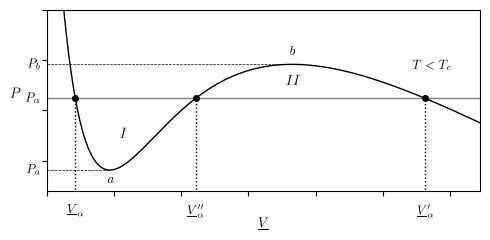

In [7]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Use a real LaTeX installation when there is one, so the figure is set in Computer
# Modern like the book, and fall back to matplotlib's own mathtext otherwise, which
# lets this notebook run in Colab too (Colab has no TeX). Verified: mathtext renders
# \underline correctly in the CM fontset.
from shutil import which
mpl.rcParams["text.usetex"] = which("latex") is not None

# Good PDF defaults
mpl.rcParams.update({
    "pdf.fonttype": 42,   # keep text as text in PDF
    "ps.fonttype": 42,
})

# Make the plot
fig, ax = plt.subplots(figsize=(5.0, 2.5))  # choose size you like

"""
Plot one isotherm and add plot annotations
"""
# Range of reduced molar volumes
Vr_min = 0.5
Vr_max = 2.1
Vr = np.linspace(Vr_min,Vr_max,1000)

# Plot the isotherm and label it
Tr = 0.95
P = rvdw_P(Vr, Tr)
ax.plot(Vr, P, '-', color="black", linewidth=1)

i = np.argmin(np.abs(Vr - label_horiz_Vr))
label_curve(ax, 0.8*Vr_max, rvdw_P(0.8*Vr_max, Tr), rf"$T<T_c$", dy=15)

# label loop extrema for the isotherm
ext = find_loop_extrema(Vr, P)  # get VA,PA,VB,PB for calculations
                                # ext["VA"], ext["PA"], ext["VB"], ext["PB"]

draw_loop_extrema(ax, ext, label_min=r"$a$", label_max=r"$b$",
                  dy_min=-3, dy_max=5, marker=False, bbox=False)

# Add a line at the vapor pressure of for this isotherm
# This finds the closest tie line in the dataframe
# Include markers at the vapor and liquid molar volumes
row = df_eq.loc[(df_eq["T"] - Tr).abs().idxmin()]
Pvap  = row["P"]
vL = row["vL"]
vV = row["vV"]
ax.plot([Vr_min, Vr_max],[Pvap, Pvap], color="gray", linewidth=1)
ax.plot(vL,Pvap,"o",ms=4,color="black")
ax.plot(vV,Pvap,"o",ms=4,color="black")

# Add P_a and P_b lines and labels
VA, PA = ext["VA"], ext["PA"]
VB, PB = ext["VB"], ext["PB"]
ax.plot([Vr_min, VA],[PA, PA], "--", color="black", linewidth=0.5)
ax.plot([Vr_min, VB],[PB, PB], "--", color="black", linewidth=0.5)
label_left_axis(ax, PA, r"$P_a$")
label_left_axis(ax, PB, r"$P_b$")
label_left_axis(ax, Pvap, r"$P_\alpha$")

# Add V-alpha and V-alpha-prime lines and labels
ax.plot([vL, vL],[0.6, Pvap], ":", color="black", linewidth=1)
label_bottom_axis(ax, vL, r"$\underline{V}_\alpha$")
ax.plot([vV, vV],[0.6, Pvap], ":", color="black", linewidth=1)
label_bottom_axis(ax, vV, r"$\underline{V}_\alpha'$")

# Label the unstable molar volume of the isotherm, V-alpha-doubleprime
VU = root_between_extrema_bisect(Tr, Pvap, ext["VA"], ext["VB"])
PU = Pvap
ax.plot(VU, PU, "o", ms=4, color="black")
ax.plot([VU, VU],[0.6, Pvap], ":", color="black", linewidth=1)
label_bottom_axis(ax, VU, r"$\underline{V}_\alpha''$")

# Label area I and area II
ax.text((((VU-vL)/2+vL)-VA)/2+VA, (Pvap-PA)/2+PA, 
        r"$I$", ha="center", va="center", fontsize=10)
ax.text(VB, (PB-Pvap)/2+Pvap, r"$II$", ha="center", va="center", fontsize=10)

"""
Adjust plot scaling, axis labels, and figure properties
""" 

# Plot scaling
plt.ylim([0.72,0.9])
plt.xlim([0.6,0.9*Vr_max])

# Axes labels
plt.xlabel(r"$\underline{V}$", labelpad=16)
plt.ylabel(r'$P$', rotation=0, labelpad=20)

# Hide the tick labels
ax.tick_params(
    labelbottom=False,
    labelleft=False
)

fig.tight_layout()

# ---- SAVE HIGH-QUALITY PDF ----
import os
os.makedirs("pdf", exist_ok=True)   # Colab starts with no pdf/ directory
fig.savefig("pdf/Fig_7.3-2.pdf", bbox_inches="tight", pad_inches=0.02)

plt.show()

# Figure 7.3-3 A low-temperature isotherm of a real fluid

This is a simpler plot of the resulting isotherm through the two-phase region.

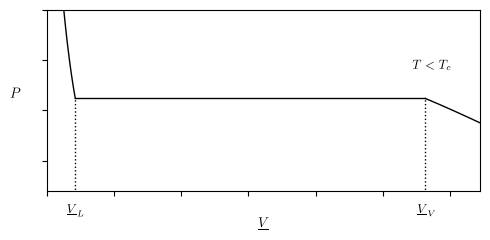

In [8]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Use a real LaTeX installation when there is one, so the figure is set in Computer
# Modern like the book, and fall back to matplotlib's own mathtext otherwise, which
# lets this notebook run in Colab too (Colab has no TeX). Verified: mathtext renders
# \underline correctly in the CM fontset.
from shutil import which
mpl.rcParams["text.usetex"] = which("latex") is not None

# Good PDF defaults
mpl.rcParams.update({
    "pdf.fonttype": 42,   # keep text as text in PDF
    "ps.fonttype": 42,
})

# Make the plot
fig, ax = plt.subplots(figsize=(5.0, 2.5))  # choose size you like

"""
Plot one isotherm and add plot annotations
"""
# Range of reduced molar volumes
Vr_min = 0.5
Vr_max = 2.1
Vr = np.linspace(Vr_min,Vr_max,1000)

# Plot the isotherm and label it
# Plot from Vr_min to vL
# at Pvap from vL to vV
# from vV to Vr_max

Tr = 0.95
P = rvdw_P(Vr, Tr)

i = np.argmin(np.abs(Vr - label_horiz_Vr))
label_curve(ax, 0.8*Vr_max, rvdw_P(0.8*Vr_max, Tr), rf"$T<T_c$", dy=15)

# Add a line at the vapor pressure of for this isotherm
# This finds the closest tie line in the dataframe
# Include markers at the vapor and liquid molar volumes
row = df_eq.loc[(df_eq["T"] - Tr).abs().idxmin()]
Pvap  = row["P"]
vL = row["vL"]
vV = row["vV"]

# Isotherm above vapor line
V = np.linspace(row["vV"], Vr_max, 1000)
ax.plot(V, rvdw_P(V, row["T"]), color='black', linestyle='-', linewidth=1)

# Isotherm below liquid line
V = np.linspace(row["vL"], Vr_min, 1000)
ax.plot(V, rvdw_P(V, row["T"]), color='black', linestyle='-', linewidth=1)

# Isotherm through the VLE
ax.plot([vL, vV],[Pvap,Pvap],color='black', linestyle='-', linewidth=1)

# Add V_L and V_V lines and labels
ax.plot([vL, vL],[0.6, Pvap], ":", color="black", linewidth=1)
label_bottom_axis(ax, vL, r"$\underline{V}_L$")
ax.plot([vV, vV],[0.6, Pvap], ":", color="black", linewidth=1)
label_bottom_axis(ax, vV, r"$\underline{V}_V$")

"""
Adjust plot scaling, axis labels, and figure properties
""" 

# Plot scaling
plt.ylim([0.72,0.9])
plt.xlim([0.6,0.9*Vr_max])

# Axes labels
plt.xlabel(r"$\underline{V}$", labelpad=16)
plt.ylabel(r'$P$', rotation=0, labelpad=20)

# Hide the tick labels
ax.tick_params(
    labelbottom=False,
    labelleft=False
)

fig.tight_layout()

# ---- SAVE HIGH-QUALITY PDF ----
import os
os.makedirs("pdf", exist_ok=True)   # Colab starts with no pdf/ directory
fig.savefig("pdf/Fig_7.3-3.pdf", bbox_inches="tight", pad_inches=0.02)

plt.show()

# Figure 7.3-4 The van der Waals fluid with the vapor-liquid coexistence region identified.

Generate a high-resolution PDF version of the van der Waals PV plot.

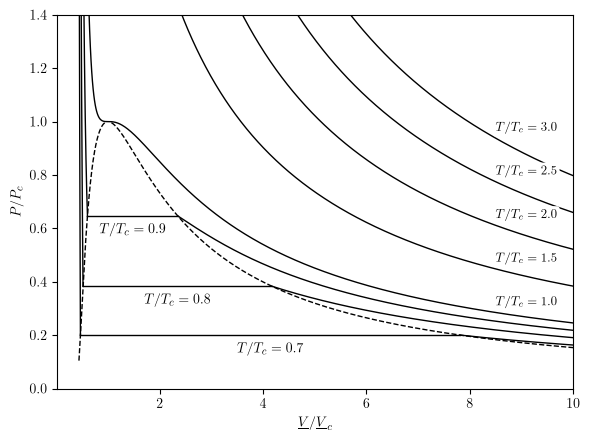

In [9]:
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.transforms import offset_copy
import numpy as np

# Use a real LaTeX installation when there is one, so the figure is set in Computer
# Modern like the book, and fall back to matplotlib's own mathtext otherwise, which
# lets this notebook run in Colab too (Colab has no TeX). Verified: mathtext renders
# \underline correctly in the CM fontset.
from shutil import which
mpl.rcParams["text.usetex"] = which("latex") is not None

# Good PDF defaults
mpl.rcParams.update({
    "pdf.fonttype": 42,   # keep text as text in PDF
    "ps.fonttype": 42,
})

fig, ax = plt.subplots(figsize=(6.0, 4.5))  # choose size you like

# plot several isotherms above the critical temperature
for Tr in np.arange(1, 3.5, 0.5):
    Vr_max = 14
    Vr_min = 0.4
    Vr = np.linspace(Vr_min, Vr_max, 1000)

    P = rvdw_P(Vr, Tr)
    ax.plot(Vr, P, '-', color="black", linewidth=1)

    # Label at Vr=8.5 using the already-computed curve (scalar-safe)
    Vlab = 8.5
    i = np.argmin(np.abs(Vr - Vlab))
    Plab = float(np.asarray(P[i]).squeeze())

    text_transform = offset_copy(ax.transData, fig=ax.figure, y=3, units='points')
    ax.text(
        float(Vr[i]),
        Plab,
        rf"$T/T_c = {Tr:.1f}$",
        ha="left",
        va="bottom",
        fontsize=9,
        transform=text_transform,
        bbox=dict(facecolor="white", edgecolor="none", boxstyle="round,pad=0.2"),
    )

# plot several isotherms below the critical temperature
for Tr in np.array([0.7, 0.8, 0.9]):
    Vr_max = 14
    Vr_min = 0.4
    Vr = np.linspace(Vr_min, Vr_max, 1000)

    row = df_eq.loc[(df_eq["T"] - Tr).abs().idxmin()]
    P  = row["P"]
    vL = row["vL"]
    vV = row["vV"]

    ax.plot([vL, vV], [P, P], color="black", linewidth=1)

    text_transform = offset_copy(ax.transData, fig=ax.figure, y=-5, units='points')
    ax.text(
        0.5 * (vL + vV),
        P,
        rf"$T/T_c = {Tr:.1f}$",
        color="black",
        ha="center",
        va="top",
        transform=text_transform,
    )

    # Above vapor line
    V = np.linspace(row["vV"], Vr_max, 1000)
    ax.plot(V, rvdw_P(V, row["T"]), color='black', linestyle='-', linewidth=1)

    # Below liquid line
    V = np.linspace(row["vL"], Vr_min, 1000)
    ax.plot(V, rvdw_P(V, row["T"]), color='black', linestyle='-', linewidth=1)

# coexistence lines behind
sns.lineplot(data=df_eq, x="vV", y="P", color="black", linewidth=1,
             ax=ax, linestyle="--", zorder=0, legend=False)
sns.lineplot(data=df_eq, x="vL", y="P", color="black", linewidth=1,
             ax=ax, linestyle="--", zorder=0, legend=False)

ax.set_xlim(.01, 10)
ax.set_ylim(0, 1.4)
ax.set_xlabel(r"$\underline{V}/ \underline{V}_c$")
ax.set_ylabel(r"$P/P_c$")

fig.tight_layout()

# ---- SAVE HIGH-QUALITY PDF ----
import os
os.makedirs("pdf", exist_ok=True)   # Colab starts with no pdf/ directory
fig.savefig("pdf/Fig_7.3-4.pdf", bbox_inches="tight", pad_inches=0.02)

plt.show()

# Exercises

1. Plot the van der Waals PV diagram on a log-log scale.
2. Locate and plot the spinodal in addition to the binodal.

# Extra figures

Here we build plots of the van der Waals EOS vapor-liquid equilibrium using different scales and incorporating the isotherms with the van der Waals loops. We draw tie lines for several reduced temperatures below the critical temperature in color and grayscale.

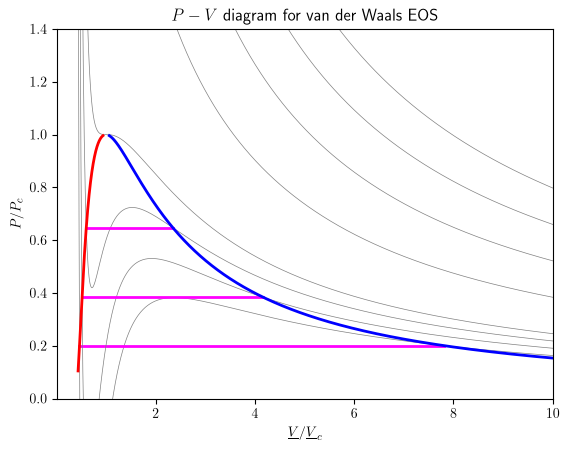

In [10]:
import seaborn as sns
import matplotlib as mpl

# Use a real LaTeX installation when there is one, so the figure is set in Computer
# Modern like the book, and fall back to matplotlib's own mathtext otherwise, which
# lets this notebook run in Colab too (Colab has no TeX). Verified: mathtext renders
# \underline correctly in the CM fontset.
from shutil import which
mpl.rcParams["text.usetex"] = which("latex") is not None

fig, ax = plt.subplots()


# plot several isotherms above the critical temperature
for Tr in np.arange(1, 3.5, 0.5) : 
    Vr_max = 10
    Vr_min = 0.4
    Vr = np.linspace(Vr_min,Vr_max,1000)

    ax.plot(Vr, rvdw_P(Vr,Tr), '-',label=Tr, color="gray", linewidth=0.5)

# plot several isotherms below the critical temperature
for Tr in np.array([0.7, 0.8, 0.9]) :  
    Vr_max = 10
    Vr_min = 0.4
    Vr = np.linspace(Vr_min,Vr_max,1000)

    ax.plot(Vr, rvdw_P(Vr,Tr), '-',label=Tr, color="gray", linewidth=0.5)

    # tie lines given Tr
    # This finds the closest tie line in the dataframe
    row = df_eq.loc[(df_eq["T"] - Tr).abs().idxmin()]
    P  = row["P"]
    vL = row["vL"]
    vV = row["vV"]
    ax.plot([vL, vV], [P, P], color="magenta", linewidth=2) 

# Plot the vapor coexistence line
sns.lineplot(data=df_eq, x="vV", y="P", color="blue", linewidth=2, ax=ax, legend=False)

# Plot the liquid coexistence line
sns.lineplot(data=df_eq, x="vL", y="P", color="red", linewidth=2, ax=ax, legend=False)

#ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
ax.set_xlim(.01, 10)
ax.set_ylim(0, 1.4)
ax.set_xlabel(r"$\underline{V}/ \underline{V}_c$")
ax.set_ylabel(r"$P/P_c$")
ax.set_title(r"$P-V$ diagram for van der Waals EOS")

#ax.set_xscale("log")

#plt.legend(frameon=True, fancybox=True, edgecolor='none')
#plt.tight_layout()

plt.show()

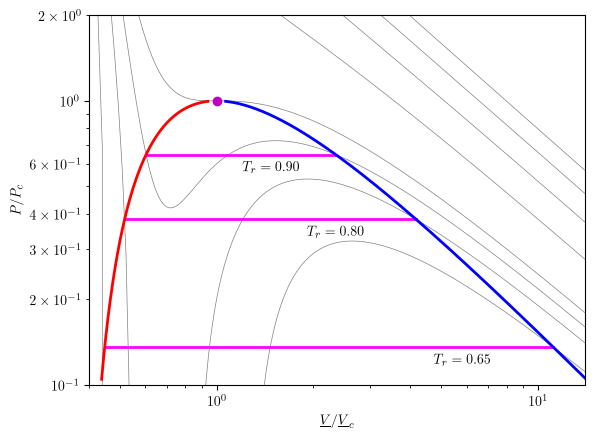

In [11]:
import seaborn as sns
import matplotlib as mpl

# For label spacing on tie lines
from matplotlib.transforms import offset_copy

# Use a real LaTeX installation when there is one, so the figure is set in Computer
# Modern like the book, and fall back to matplotlib's own mathtext otherwise, which
# lets this notebook run in Colab too (Colab has no TeX). Verified: mathtext renders
# \underline correctly in the CM fontset.
from shutil import which
mpl.rcParams["text.usetex"] = which("latex") is not None

fig, ax = plt.subplots()

# plot several isotherms above the critical temperature
for Tr in np.arange(1, 3.5, 0.5) : 
    Vr_max = 14
    Vr_min = 0.4
    Vr = np.linspace(Vr_min,Vr_max,1000)

    ax.plot(Vr, rvdw_P(Vr,Tr), '-',label=Tr, color="gray", linewidth=0.5)

# plot several isotherms below the critical temperature
for Tr in np.array([0.65, 0.8, 0.9]) : 
    Vr_max = 14
    Vr_min = 0.4
    Vr = np.linspace(Vr_min,Vr_max,1000)

    ax.plot(Vr, rvdw_P(Vr,Tr), '-',label=Tr, color="gray", linewidth=0.5)

    # tie lines given Tr
    # This finds the closest tie line in the dataframe
    row = df_eq.loc[(df_eq["T"] - Tr).abs().idxmin()]
    P  = row["P"]
    vL = row["vL"]
    vV = row["vV"]
    ax.plot([vL, vV], [P, P], color="magenta", linewidth=2) 

    text_transform = offset_copy(ax.transData, fig=ax.figure, y=-5, units='points')

    ax.text(
        0.5 * (vL + vV),
        P,
        rf"$T_r = {Tr:.2f}$",
        color="black",
        ha="center",
        va="top",
        transform=text_transform
    )

# Plot the vapor coexistence line
sns.lineplot(data=df_eq, x="vV", y="P", color="blue", linewidth=2, ax=ax, legend=False)

# Plot the liquid coexistence line
sns.lineplot(data=df_eq, x="vL", y="P", color="red", linewidth=2, ax=ax, legend=False)

ax.set_xlim(.4, 14)
ax.set_ylim(0.1, 2)
ax.set_xlabel(r"$\underline{V}/ \underline{V}_c$")
ax.set_ylabel(r"$P/P_c$")
#ax.set_title(r"$P-V$ diagram for van der Waals EOS")
ax.plot(1,1,"mo")


#ax.set_xscale("log")

#plt.legend(frameon=True, fancybox=True, edgecolor='none')
#plt.tight_layout()

ax.set_xscale("log")
ax.set_yscale("log")
plt.show()

## Grayscale, log-log scale

Notice that the "equal areas" of the van der Waals loop is more difficult to see on this scale. One of the interesting things about this plot is the shape of the binodal along the vapor curve and the fact that, far from the critical point, the vapor isotherms as they approach the binodal behave nearly ideally. That is an assumption made deriving the Clausius-Clapeyron equation.

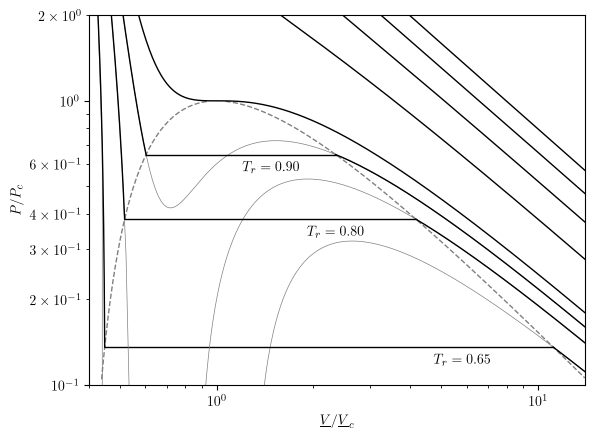

In [12]:
import seaborn as sns
import matplotlib as mpl

# For label spacing on tie lines
from matplotlib.transforms import offset_copy

# Use a real LaTeX installation when there is one, so the figure is set in Computer
# Modern like the book, and fall back to matplotlib's own mathtext otherwise, which
# lets this notebook run in Colab too (Colab has no TeX). Verified: mathtext renders
# \underline correctly in the CM fontset.
from shutil import which
mpl.rcParams["text.usetex"] = which("latex") is not None

fig, ax = plt.subplots()

# plot several isotherms above the critical temperature
for Tr in np.arange(1, 3.5, 0.5) : 
    Vr_max = 14
    Vr_min = 0.4
    Vr = np.linspace(Vr_min,Vr_max,1000)

    ax.plot(Vr, rvdw_P(Vr,Tr), '-',label=Tr, color="black", linewidth=1)

# plot several isotherms below the critical temperature
for Tr in np.array([0.65, 0.8, 0.9]) : 
    Vr_max = 14
    Vr_min = 0.4
    Vr = np.linspace(Vr_min,Vr_max,1000)

    ax.plot(Vr, rvdw_P(Vr,Tr), '',label=Tr, color="gray", linewidth=0.5)

    # tie lines given Tr
    # This finds the closest tie line in the dataframe
    row = df_eq.loc[(df_eq["T"] - Tr).abs().idxmin()]
    P  = row["P"]
    vL = row["vL"]
    vV = row["vV"]
    ax.plot([vL, vV], [P, P], color="black", linewidth=1) 

    text_transform = offset_copy(ax.transData, fig=ax.figure, y=-5, units='points')

    ax.text(
        0.5 * (vL + vV),
        P,
        rf"$T_r = {Tr:.2f}$",
        color="black",
        ha="center",
        va="top",
        transform=text_transform
    )

    # Plot the isotherm above the vapor line
    V = np.linspace(row["vV"],Vr_max,1000)
    plt.plot(V, rvdw_P(V,row["T"]), color='black', linestyle='-', linewidth=1)

    # Plot the isotherm below the liquid line
    V = np.linspace(row["vL"],Vr_min,1000)
    plt.plot(V, rvdw_P(V,row["T"]), color='black', linestyle='-', linewidth=1)

# Plot the vapor coexistence line
sns.lineplot(data=df_eq, 
             x="vV", y="P", 
             color="gray", 
             linewidth=1, 
             ax=ax, 
             linestyle="--",
             zorder=0,
             legend=False)

# Plot the liquid coexistence line
sns.lineplot(data=df_eq, 
             x="vL", y="P", 
             color="gray", 
             linewidth=1, 
             ax=ax, 
             linestyle="--",
             zorder=0,
             legend=False)

ax.set_xlim(.4, 14)
ax.set_ylim(0.1, 2)
ax.set_xlabel(r"$\underline{V}/ \underline{V}_c$")
ax.set_ylabel(r"$P/P_c$")

ax.set_xscale("log")
ax.set_yscale("log")
plt.show()